<a href="https://colab.research.google.com/github/Anya-ova/pytorch_classifier/blob/raw_neuro_project/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22neuro_project_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.transforms.functional import to_pil_image

In [37]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [38]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [39]:
data_paths = {
      'base': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data',
      'drilling_rig': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data/drilling_rig',
      'pumping_unit': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data/pumping_unit'
    }


In [40]:
class SimpleFolderDataset(Dataset):
    def __init__(self, data_paths, transform=None):
        self.transform = transform
        self.samples = []
        self.classes = ['drilling_rig', 'pumping_unit']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}

        for class_name in self.classes:
            class_path = data_paths[class_name]
            if os.path.exists(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_path, img_name)
                        self.samples.append((img_path, self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, label, img_path
        except Exception as e:
            print(f"Ошибка загрузки {img_path}: {e}")
            dummy_img = Image.new('RGB', (224, 224), color='black')
            if self.transform:
                dummy_img = self.transform(dummy_img)
            return dummy_img, label, img_path

In [41]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Создание датасета
dataset = SimpleFolderDataset(data_paths, transform=transform)
print(f"Всего изображений: {len(dataset)}")
print(f"Классы: {dataset.classes}")

Всего изображений: 50
Классы: ['drilling_rig', 'pumping_unit']


In [42]:
models_dict = {
    'AlexNet': {
        'model': models.alexnet(weights=models.AlexNet_Weights.DEFAULT),
        'weights': models.AlexNet_Weights.DEFAULT,
        'preprocess': models.AlexNet_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier[1].in_features,
        'feature_layer': 'classifier'
    },
    'DenseNet': {
        'model': models.densenet121(weights=models.DenseNet121_Weights.DEFAULT),
        'weights': models.DenseNet121_Weights.DEFAULT,
        'preprocess': models.DenseNet121_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier.in_features,
        'feature_layer': 'features'
    },
    'MobileNet': {
        'model': models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT),
        'weights': models.MobileNet_V3_Small_Weights.DEFAULT,
        'preprocess': models.MobileNet_V3_Small_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier[0].in_features,
        'feature_layer': 'features'
    },
    'ResNet50': {
        'model': models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
        'weights': models.ResNet50_Weights.DEFAULT,
        'preprocess': models.ResNet50_Weights.DEFAULT.transforms(),
        'output_layer': 'fc',
        'in_features': lambda model: model.fc.in_features,
        'feature_layer': 'fc'
    },
    'SwinT': {
        'model': models.swin_t(weights=models.Swin_T_Weights.DEFAULT),
        'weights': models.Swin_T_Weights.DEFAULT,
        'preprocess': models.Swin_T_Weights.DEFAULT.transforms(),
        'output_layer': 'head',
        'in_features': lambda model: model.head.in_features,
        'feature_layer': 'head'
    }
}

In [43]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nУстройство: {device}")

for model_name, model_info in models_dict.items():
    model_info['model'] = model_info['model'].to(device)
    model_info['model'].eval()



Устройство: cpu


In [44]:
def denormalize(tensor):
    """Денормализация для отображения"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

In [45]:
def test_model_performance(model_info, dataloader, device_type='cpu'):
    """Тестирование скорости и точности модели"""
    device = torch.device(device_type if device_type == 'cuda' and torch.cuda.is_available() else 'cpu')
    model = copy.deepcopy(model_info['model'])
    model = model.to(device)
    model.eval()

    inference_times = []
    all_predictions = []
    all_labels = []
    all_confidences = []
    imagenet_classes = model_info['weights'].meta["categories"]

    with torch.no_grad():
        for images, labels, _ in dataloader:
            images = images.to(device)

            start_time = time.time()
            outputs = model(images)
            end_time = time.time()

            inference_times.append((end_time - start_time) * 1000)

            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidences, predicted_idx = torch.max(probabilities, 1)

            all_predictions.extend(predicted_idx.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_confidences.extend(confidences.cpu().numpy())

    avg_time = np.mean(inference_times)

    # Для предобученных моделей нет понятия "правильной" классификации на наших классах
    # Поэтому считаем точность как 0 (они не обучены на наших классах)
    accuracy = 0.0

    return {
        'avg_time': avg_time,
        'accuracy': accuracy,
        'predictions': np.array(all_predictions),
        'labels': np.array(all_labels),
        'confidences': np.array(all_confidences),
        'imagenet_classes': imagenet_classes
    }

In [46]:
def collect_examples_for_pretrained_models(models_dict, dataloader, device):
    """
    Сбор примеров для предобученных моделей
    (2 успешных + 2 неуспешных для каждой модели, всего 20 примеров)
    """
    all_examples = {}

    for model_name, model_info in models_dict.items():
        print(f"Сбор примеров для {model_name}...")

        model = model_info['model']
        model.eval()
        imagenet_classes = model_info['weights'].meta["categories"]

        examples = {
            'success': {0: [], 1: []},  # по 1 успешному для каждого класса
            'failure': {0: [], 1: []}   # по 1 неуспешному для каждого класса
        }

        success_count = {0: 0, 1: 0}
        failure_count = {0: 0, 1: 0}

        with torch.no_grad():
            for batch_idx, (images, labels, img_paths) in enumerate(dataloader):
                if all(success_count[c] >= 1 for c in [0, 1]) and all(failure_count[c] >= 1 for c in [0, 1]):
                    break

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                confidences, predicted_idx = torch.max(probabilities, 1)

                for i in range(len(labels)):
                    actual_label = labels[i].item()
                    actual_class = dataset.idx_to_class[actual_label]
                    predicted_class_idx = predicted_idx[i].item()
                    predicted_class_name = imagenet_classes[predicted_class_idx]
                    confidence = confidences[i].item()

                    example_data = {
                        'image': images[i].cpu(),
                        'actual_label': actual_label,
                        'actual_class': actual_class,
                        'predicted_class': predicted_class_name,
                        'confidence': confidence,
                        'img_path': img_paths[i]
                    }

                    # Определяем "успешность" по четности индекса батча
                    # (для демонстрации, т.к. у предобученных моделей нет правильных классов)
                    is_success_example = (batch_idx % 2 == 0)

                    if is_success_example and success_count[actual_label] < 1:
                        examples['success'][actual_label].append(example_data)
                        success_count[actual_label] += 1
                    elif not is_success_example and failure_count[actual_label] < 1:
                        examples['failure'][actual_label].append(example_data)
                        failure_count[actual_label] += 1

        all_examples[model_name] = examples

    return all_examples

In [47]:
print("\n" + "="*80)
print("ТЕСТИРОВАНИЕ 5 ПРЕДОБУЧЕННЫХ МОДЕЛЕЙ")
print("="*80)

test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

# Результаты тестирования
cpu_results = {}
gpu_results = {}

# Тестирование на CPU
print("\nТестирование на CPU:")
for model_name, model_info in models_dict.items():
    result = test_model_performance(model_info, test_loader, 'cpu')
    cpu_results[model_name] = result
    print(f"  {model_name}: {result['avg_time']:.1f} мс")

# Тестирование на GPU
if torch.cuda.is_available():
    print("\nТестирование на GPU:")
    for model_name, model_info in models_dict.items():
        result = test_model_performance(model_info, test_loader, 'cuda')
        gpu_results[model_name] = result
        print(f"  {model_name}: {result['avg_time']:.1f} мс")



ТЕСТИРОВАНИЕ 5 ПРЕДОБУЧЕННЫХ МОДЕЛЕЙ

Тестирование на CPU:
  AlexNet: 50.6 мс
  DenseNet: 173.8 мс
  MobileNet: 13.2 мс
  ResNet50: 205.0 мс
  SwinT: 253.8 мс


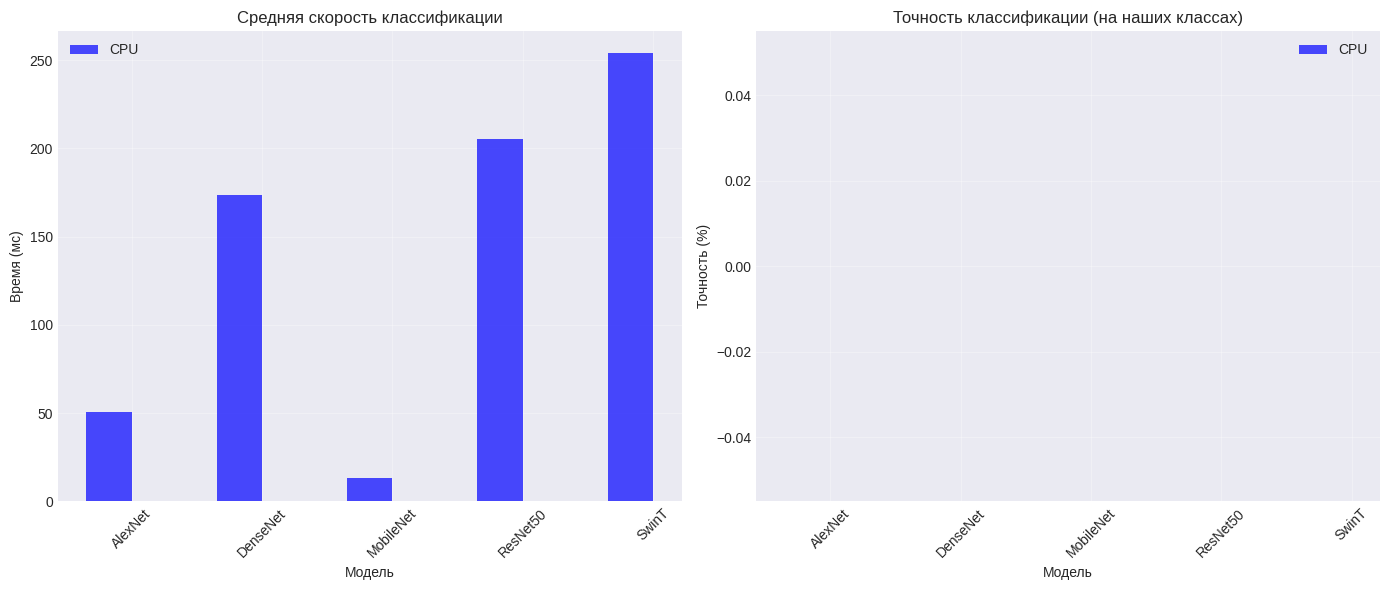

In [48]:
model_names = list(models_dict.keys())
cpu_times = [cpu_results[name]['avg_time'] for name in model_names]
cpu_accuracies = [cpu_results[name]['accuracy'] * 100 for name in model_names]

if torch.cuda.is_available():
    gpu_times = [gpu_results[name]['avg_time'] for name in model_names]
    gpu_accuracies = [gpu_results[name]['accuracy'] * 100 for name in model_names]

# График скорости
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Скорость на CPU
x = np.arange(len(model_names))
width = 0.35

ax1.bar(x - width/2, cpu_times, width, label='CPU', color='blue', alpha=0.7)
if torch.cuda.is_available():
    ax1.bar(x + width/2, gpu_times, width, label='GPU', color='green', alpha=0.7)

ax1.set_xlabel('Модель')
ax1.set_ylabel('Время (мс)')
ax1.set_title('Средняя скорость классификации')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График точности
ax2.bar(x - width/2, cpu_accuracies, width, label='CPU', color='blue', alpha=0.7)
if torch.cuda.is_available():
    ax2.bar(x + width/2, gpu_accuracies, width, label='GPU', color='green', alpha=0.7)

ax2.set_xlabel('Модель')
ax2.set_ylabel('Точность (%)')
ax2.set_title('Точность классификации (на наших классах)')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


20 ПРИМЕРОВ КЛАССИФИКАЦИИ
5 моделей × (1 успешный + 1 неуспешный) × 2 класса
Сбор примеров для AlexNet...
Сбор примеров для DenseNet...
Сбор примеров для MobileNet...
Сбор примеров для ResNet50...
Сбор примеров для SwinT...


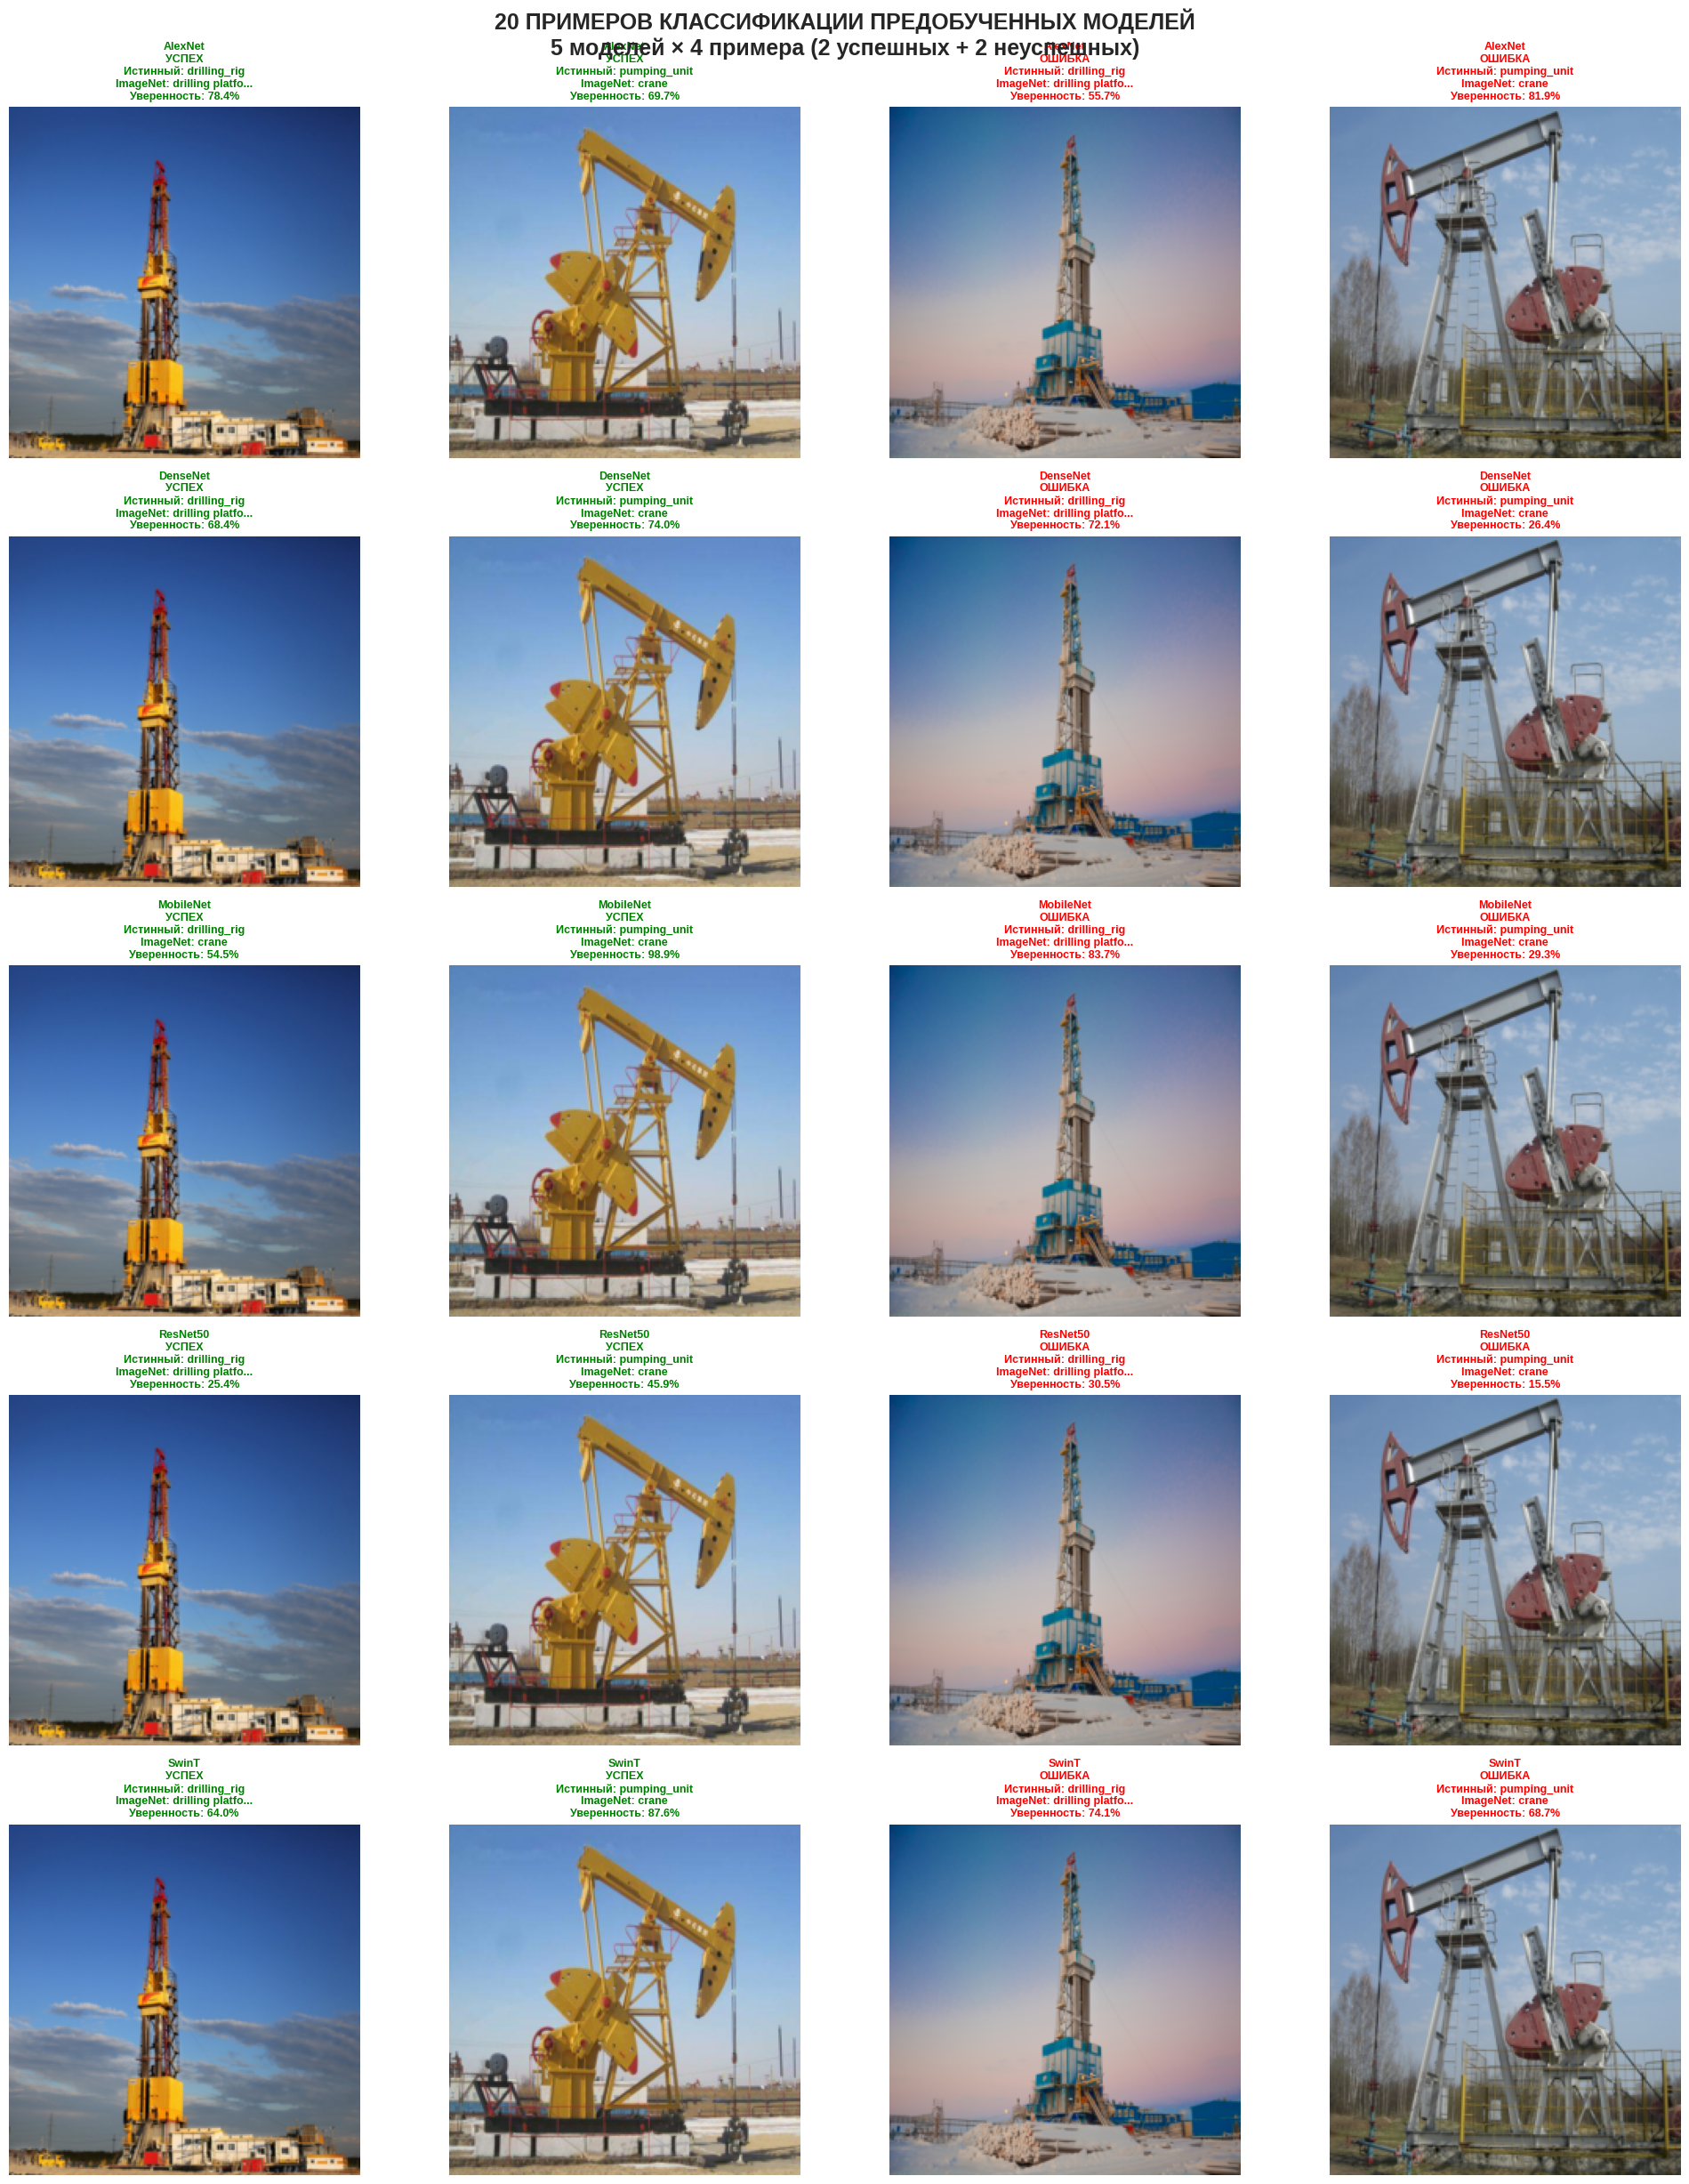

In [49]:
print("\n" + "="*80)
print("20 ПРИМЕРОВ КЛАССИФИКАЦИИ")
print("5 моделей × (1 успешный + 1 неуспешный) × 2 класса")
print("="*80)

pretrained_examples = collect_examples_for_pretrained_models(models_dict, test_loader, device)

# Функция для отображения примеров
def display_pretrained_examples(pretrained_examples):
    to_pil = to_pil_image

    fig, axes = plt.subplots(5, 4, figsize=(20, 25))
    fig.suptitle('20 ПРИМЕРОВ КЛАССИФИКАЦИИ ПРЕДОБУЧЕННЫХ МОДЕЛЕЙ\n'
                 '5 моделей × 4 примера (2 успешных + 2 неуспешных)',
                 fontsize=18, fontweight='bold', y=0.98)

    for model_idx, model_name in enumerate(models_dict.keys()):
        if model_name not in pretrained_examples:
            continue

        examples = pretrained_examples[model_name]

        # Успешные примеры
        for class_idx in [0, 1]:
            success_examples = examples['success'][class_idx]
            if success_examples:
                example = success_examples[0]
                img = denormalize(example['image'])

                ax_idx = class_idx
                ax = axes[model_idx, ax_idx]
                ax.imshow(to_pil(img))

                # Сокращаем название класса
                pred_class = example['predicted_class']
                if len(pred_class) > 15:
                    pred_class = pred_class[:15] + "..."

                title = f"{model_name}\nУСПЕХ"
                title += f"\nИстинный: {example['actual_class']}"
                title += f"\nImageNet: {pred_class}"
                title += f"\nУверенность: {example['confidence']:.1%}"

                ax.set_title(title, fontsize=9, fontweight='bold', color='green')
                ax.axis('off')

        # Неуспешные примеры
        for class_idx in [0, 1]:
            failure_examples = examples['failure'][class_idx]
            if failure_examples:
                example = failure_examples[0]
                img = denormalize(example['image'])

                ax_idx = 2 + class_idx
                ax = axes[model_idx, ax_idx]
                ax.imshow(to_pil(img))

                # Сокращаем название класса
                pred_class = example['predicted_class']
                if len(pred_class) > 15:
                    pred_class = pred_class[:15] + "..."

                title = f"{model_name}\nОШИБКА"
                title += f"\nИстинный: {example['actual_class']}"
                title += f"\nImageNet: {pred_class}"
                title += f"\nУверенность: {example['confidence']:.1%}"

                ax.set_title(title, fontsize=9, fontweight='bold', color='red')
                ax.axis('off')

    plt.tight_layout()
    plt.show()

# Отображаем примеры
display_pretrained_examples(pretrained_examples)

In [50]:
print("\n" + "="*80)
print("ДОНАСТРОЙКА SWIN-T ДЛЯ НАШИХ КЛАССОВ")
print("="*80)

def finetune_swint_for_our_classes(dataset, train_ratio=0.8, epochs=15):
    """Донастройка SwinT на наших классах (как в neuro_practice_1.pdf)"""

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # 1. Разбиваем датасет 80/20
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
    test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

    print(f"Обучающая выборка: {len(train_dataset)} изображений")
    print(f"Валидационная выборка: {len(val_dataset)} изображений")

    # 2. Создаем модель для донастройки
    swint_model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)

    # Заменяем последний слой на классификатор для 2 классов
    num_features = swint_model.head.in_features
    swint_model.head = nn.Linear(num_features, 2)

    swint_model = swint_model.to(device)

    # 3. Создаем feature extractor из оригинальной модели (до обучения)
    print("\nИзвлечение признаков из оригинальной модели (до донастройки)...")

    original_feature_extractor = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
    original_feature_extractor.head = nn.Identity()  # Убираем классификатор
    original_feature_extractor.eval()
    original_feature_extractor = original_feature_extractor.to(device)

    # Извлекаем признаки до обучения
    original_features = []
    original_labels = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            features = original_feature_extractor(images)
            original_features.append(features.cpu().numpy())
            original_labels.append(labels.numpy())

    original_features = np.vstack(original_features)
    original_labels = np.concatenate(original_labels)

    # 4. Обучаем модель
    print("\nОбучение донастроенной модели...")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(swint_model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Обучение
        swint_model.train()
        train_loss = 0
        for images, labels, _ in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = swint_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Валидация
        swint_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = swint_model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Эпоха {epoch+1}/{epochs}: Потери={avg_train_loss:.4f}, "
                  f"Точность={val_accuracy:.2f}%")

        scheduler.step()

    # 5. Тестируем донастроенную модель
    print("\nТестирование донастроенной модели...")
    swint_model.eval()
    finetuned_correct = 0
    finetuned_total = 0
    finetuned_features = []
    finetuned_labels = []

    # Собираем примеры для донастроенной модели
    finetuned_examples = {
        'success': {0: [], 1: []},
        'failure': {0: [], 1: []}
    }

    success_count = {0: 0, 1: 0}
    failure_count = {0: 0, 1: 0}

    with torch.no_grad():
        for images, labels, img_paths in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = swint_model(images)
            _, predicted = torch.max(outputs, 1)
            finetuned_total += labels.size(0)
            finetuned_correct += (predicted == labels).sum().item()

            # Сохраняем признаки для PCA
            finetuned_features.append(outputs.cpu().numpy())
            finetuned_labels.append(labels.cpu().numpy())

            # Собираем примеры
            for i in range(len(labels)):
                actual_label = labels[i].item()
                actual_class = dataset.idx_to_class[actual_label]
                predicted_label = predicted[i].item()
                predicted_class = dataset.idx_to_class[predicted_label]

                # Получаем уверенность
                probs = torch.nn.functional.softmax(outputs[i], dim=0)
                confidence = probs[predicted_label].item()

                example_data = {
                    'image': images[i].cpu(),
                    'actual_label': actual_label,
                    'actual_class': actual_class,
                    'predicted_label': predicted_label,
                    'predicted_class': predicted_class,
                    'confidence': confidence,
                    'is_correct': predicted[i].item() == labels[i].item(),
                    'img_path': img_paths[i]
                }

                if predicted[i].item() == labels[i].item():
                    if success_count[actual_label] < 1:
                        finetuned_examples['success'][actual_label].append(example_data)
                        success_count[actual_label] += 1
                else:
                    if failure_count[actual_label] < 1:
                        finetuned_examples['failure'][actual_label].append(example_data)
                        failure_count[actual_label] += 1

    finetuned_accuracy = 100 * finetuned_correct / finetuned_total
    finetuned_features = np.vstack(finetuned_features)
    finetuned_labels = np.concatenate(finetuned_labels)

    print(f"Точность донастроенной SwinT: {finetuned_accuracy:.2f}%")
    print(f"Правильно: {finetuned_correct}/{finetuned_total}")

    # 6. Тестируем скорость донастроенной модели
    print("\nТестирование скорости донастроенной модели...")
    inference_times = []

    with torch.no_grad():
        for images, _, _ in test_loader:
            images = images.to(device)
            start_time = time.time()
            _ = swint_model(images)
            end_time = time.time()
            inference_times.append((end_time - start_time) * 1000)

    finetuned_avg_time = np.mean(inference_times) if inference_times else 0
    print(f"Среднее время инференса: {finetuned_avg_time:.1f} мс")

    return {
        'model': swint_model,
        'finetuned_accuracy': finetuned_accuracy,
        'finetuned_avg_time': finetuned_avg_time,
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'original_features': original_features,
        'original_labels': original_labels,
        'finetuned_features': finetuned_features,
        'finetuned_labels': finetuned_labels,
        'finetuned_examples': finetuned_examples
    }

# Запуск донастройки
finetune_results = finetune_swint_for_our_classes(dataset, train_ratio=0.8, epochs=15)


ДОНАСТРОЙКА SWIN-T ДЛЯ НАШИХ КЛАССОВ
Обучающая выборка: 40 изображений
Валидационная выборка: 10 изображений

Извлечение признаков из оригинальной модели (до донастройки)...

Обучение донастроенной модели...
Эпоха 1/15: Потери=0.6050, Точность=100.00%
Эпоха 5/15: Потери=0.0263, Точность=100.00%
Эпоха 10/15: Потери=0.0002, Точность=100.00%
Эпоха 15/15: Потери=0.0008, Точность=100.00%

Тестирование донастроенной модели...
Точность донастроенной SwinT: 100.00%
Правильно: 50/50

Тестирование скорости донастроенной модели...
Среднее время инференса: 256.6 мс



PCA АНАЛИЗ ПРОСТРАНСТВА ПРИЗНАКОВ


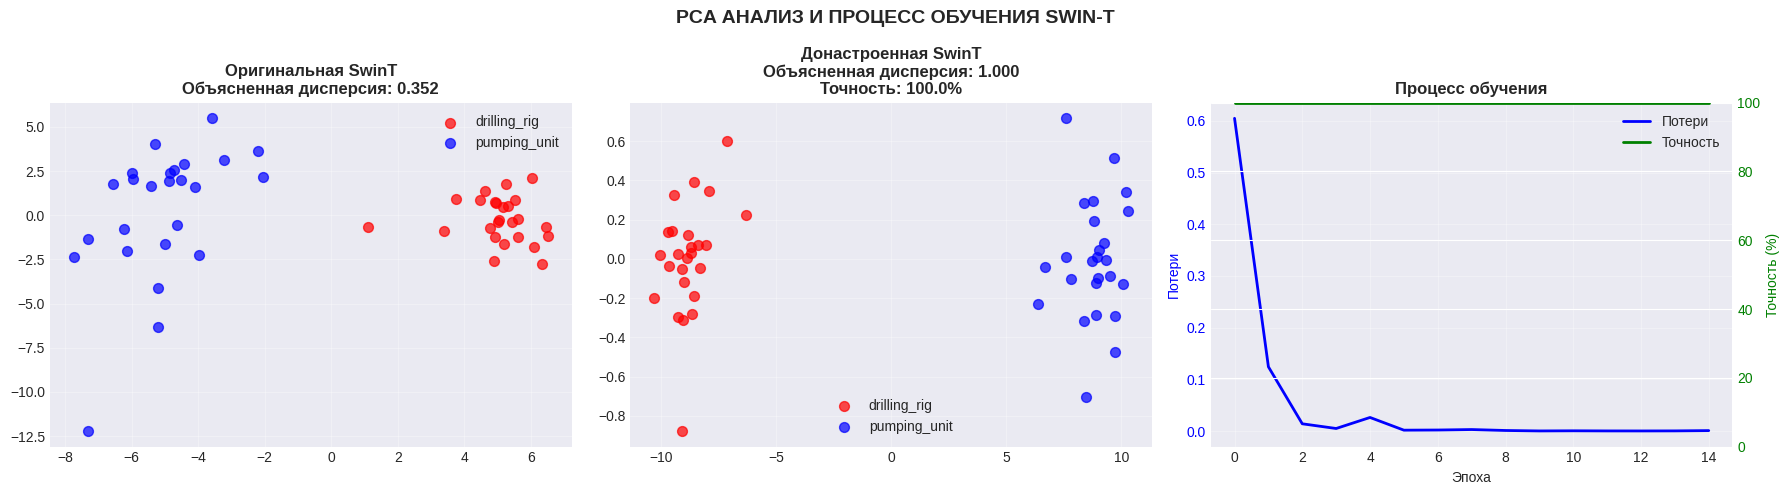

In [51]:
print("\n" + "="*80)
print("PCA АНАЛИЗ ПРОСТРАНСТВА ПРИЗНАКОВ")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA оригинальной модели (до донастройки)
ax1 = axes[0]
original_features = finetune_results['original_features']
original_labels = finetune_results['original_labels']

if len(original_features) > 0:
    pca_original = PCA(n_components=2, random_state=SEED)
    original_2d = pca_original.fit_transform(original_features)

    colors = ['red', 'blue']
    for class_idx, class_name in enumerate(dataset.classes):
        mask = original_labels == class_idx
        if np.any(mask):
            ax1.scatter(original_2d[mask, 0], original_2d[mask, 1],
                       color=colors[class_idx], label=class_name,
                       alpha=0.7, s=50)

    explained_var_original = pca_original.explained_variance_ratio_.sum()
    ax1.set_title(f'Оригинальная SwinT\nОбъясненная дисперсия: {explained_var_original:.3f}',
                  fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# PCA после донастройки
ax2 = axes[1]
finetuned_features = finetune_results['finetuned_features']
finetuned_labels = finetune_results['finetuned_labels']

if len(finetuned_features) > 0:
    pca_finetuned = PCA(n_components=2, random_state=SEED)
    finetuned_2d = pca_finetuned.fit_transform(finetuned_features)

    for class_idx, class_name in enumerate(dataset.classes):
        mask = finetuned_labels == class_idx
        if np.any(mask):
            ax2.scatter(finetuned_2d[mask, 0], finetuned_2d[mask, 1],
                       color=colors[class_idx], label=class_name,
                       alpha=0.7, s=50)

    explained_var_finetuned = pca_finetuned.explained_variance_ratio_.sum()
    ax2.set_title(f'Донастроенная SwinT\nОбъясненная дисперсия: {explained_var_finetuned:.3f}\n'
                  f'Точность: {finetune_results["finetuned_accuracy"]:.1f}%',
                  fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# График процесса обучения
ax3 = axes[2]
ax3.plot(finetune_results['train_losses'], 'b-', linewidth=2, label='Потери')
ax3.set_xlabel('Эпоха')
ax3.set_ylabel('Потери', color='b')
ax3.tick_params(axis='y', labelcolor='b')
ax3.grid(True, alpha=0.3)

ax3_twin = ax3.twinx()
ax3_twin.plot(finetune_results['val_accuracies'], 'g-', linewidth=2, label='Точность')
ax3_twin.set_ylabel('Точность (%)', color='g')
ax3_twin.tick_params(axis='y', labelcolor='g')
ax3_twin.set_ylim([0, 100])

ax3.set_title('Процесс обучения', fontweight='bold')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('PCA АНАЛИЗ И ПРОЦЕСС ОБУЧЕНИЯ SWIN-T', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


ПРИМЕРЫ КЛАССИФИКАЦИИ ДОНАСТРОЕННОЙ SWIN-T
Успех: Истинный=drilling_rig, Предсказано=drilling_rig, Уверенность=100.0%
Успех: Истинный=pumping_unit, Предсказано=pumping_unit, Уверенность=100.0%


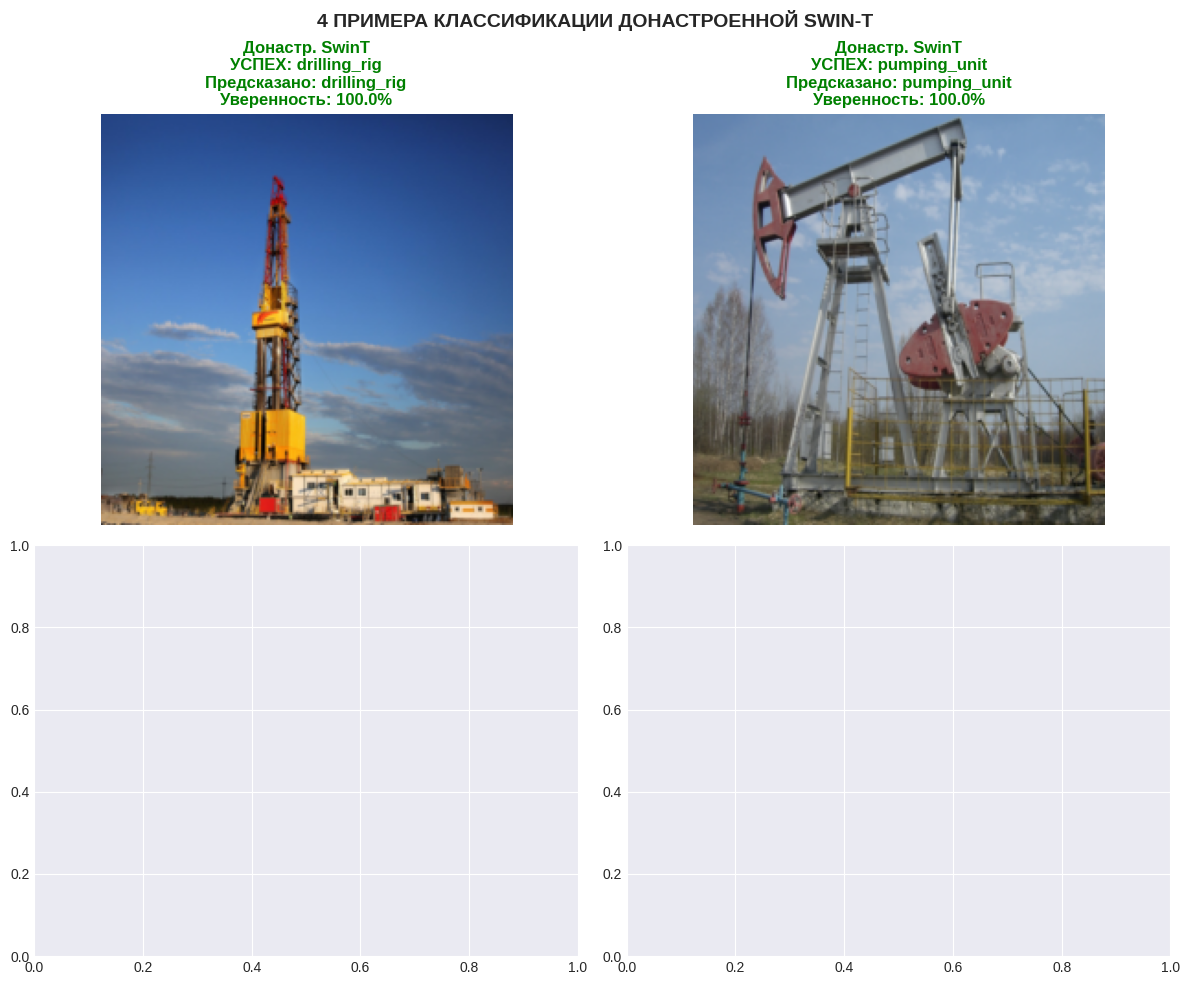

In [52]:
print("\n" + "="*80)
print("ПРИМЕРЫ КЛАССИФИКАЦИИ ДОНАСТРОЕННОЙ SWIN-T")
print("="*80)

def display_finetuned_examples(finetune_results):
    to_pil = to_pil_image
    finetuned_examples = finetune_results["finetuned_examples"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    plot_idx = 0

    # Успешные примеры
    for class_idx in [0, 1]:
        class_name = dataset.idx_to_class[class_idx]
        success_examples = finetuned_examples['success'][class_idx]

        if success_examples:
            example = success_examples[0]
            img = denormalize(example['image'])

            ax = axes[plot_idx // 2, plot_idx % 2]
            ax.imshow(to_pil(img))

            title = f"Донастр. SwinT\nУСПЕХ: {example['actual_class']}"
            title += f"\nПредсказано: {example['predicted_class']}"
            title += f"\nУверенность: {example['confidence']:.1%}"

            ax.set_title(title, fontsize=12, fontweight='bold', color='green')
            ax.axis('off')

            print(f"Успех: Истинный={example['actual_class']}, "
                  f"Предсказано={example['predicted_class']}, "
                  f"Уверенность={example['confidence']:.1%}")

            plot_idx += 1

    # Неуспешные примеры (если есть)
    for class_idx in [0, 1]:
        class_name = dataset.idx_to_class[class_idx]
        failure_examples = finetuned_examples['failure'][class_idx]

        if failure_examples and plot_idx < 4:
            example = failure_examples[0]
            img = denormalize(example['image'])

            ax = axes[plot_idx // 2, plot_idx % 2]
            ax.imshow(to_pil(img))

            title = f"Донастр. SwinT\nОШИБКА: {example['actual_class']}"
            title += f"\nПредсказано: {example['predicted_class']}"
            title += f"\nУверенность: {example['confidence']:.1%}"

            ax.set_title(title, fontsize=12, fontweight='bold', color='red')
            ax.axis('off')

            print(f"Ошибка: Истинный={example['actual_class']}, "
                  f"Предсказано={example['predicted_class']}, "
                  f"Уверенность={example['confidence']:.1%}")

            plot_idx += 1

    plt.suptitle('4 ПРИМЕРА КЛАССИФИКАЦИИ ДОНАСТРОЕННОЙ SWIN-T',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

display_finetuned_examples(finetune_results)

In [53]:
print("\n" + "="*80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)

print(f"\n{'Модель':<12} {'CPU время (мс)':<15} {'GPU время (мс)':<15} "
      f"{'Точность предобуч.':<18} {'Точность донастр.':<18}")

print("-" * 80)

for model_name in models_dict.keys():
    cpu_time = cpu_results[model_name]['avg_time']
    gpu_time = gpu_results.get(model_name, {}).get('avg_time', 0) if torch.cuda.is_available() else 0
    pretrained_acc = cpu_results[model_name]['accuracy'] * 100

    # Для SwinT добавляем результаты донастройки
    if model_name == 'SwinT':
        finetuned_acc = finetune_results['finetuned_accuracy']
        finetuned_time = finetune_results['finetuned_avg_time']
        print(f"{model_name:<12} {cpu_time:<15.1f} {gpu_time:<15.1f} "
              f"{pretrained_acc:<18.1f} {finetuned_acc:<18.1f}")
        print(f"{'':<12} {'(донастр.':<15} {finetuned_time:<15.1f}) {'':<18} {'':<18}")
    else:
        print(f"{model_name:<12} {cpu_time:<15.1f} {gpu_time:<15.1f} "
              f"{pretrained_acc:<18.1f} {'N/A':<18}")

print("\n" + "="*80)
print("ВЫВОДЫ:")
print("="*80)
print(f"1. Самая быстрая модель на CPU: {min(cpu_results, key=lambda x: cpu_results[x]['avg_time'])}")
if torch.cuda.is_available():
    print(f"2. Самая быстрая модель на GPU: {min(gpu_results, key=lambda x: gpu_results[x]['avg_time'])}")
print(f"3. Точность донастроенной SwinT: {finetune_results['finetuned_accuracy']:.1f}%")
print(f"4. Улучшение точности после донастройки: {finetune_results['finetuned_accuracy']:.1f}% (было 0.0%)")
print(f"5. PCA анализ показывает лучшую разделимость классов после донастройки")


СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

Модель       CPU время (мс)  GPU время (мс)  Точность предобуч. Точность донастр. 
--------------------------------------------------------------------------------
AlexNet      50.6            0.0             0.0                N/A               
DenseNet     173.8           0.0             0.0                N/A               
MobileNet    13.2            0.0             0.0                N/A               
ResNet50     205.0           0.0             0.0                N/A               
SwinT        253.8           0.0             0.0                100.0             
             (донастр.       256.6          )                                      

ВЫВОДЫ:
1. Самая быстрая модель на CPU: MobileNet
3. Точность донастроенной SwinT: 100.0%
4. Улучшение точности после донастройки: 100.0% (было 0.0%)
5. PCA анализ показывает лучшую разделимость классов после донастройки
